## Step 1 — Install the required libraries

We use common Python libraries:
- `librosa` for reading audio and extracting sound features
- `numpy` for numerical operations
- `pandas` for tables
- `scikit-learn` for Random Forest, SVM and evaluation
- `tensorflow` for the CNN
- `matplotlib` and `seaborn` for graphs

In [ ]:
!pip -q install librosa soundfile scikit-learn tensorflow seaborn

## Step 2 — Import libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras import layers, models

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3 — Connect Google Drive

The dataset is stored inside the SonicSentinel folder in Google Drive.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/SonicSentinel/Dataset"

print("Dataset folder:", DATASET_DIR)
print("Folder exists:", os.path.exists(DATASET_DIR))

Dataset folder: /content/drive/MyDrive/SonicSentinel/Dataset
Folder exists: True


## Step 4 — Define the 10 SonicSentinel classes

The folder names below are the labels used by the models.

In [ ]:
CLASSES = [
    "Machinery Fault",
    "Glass Breaking",
    "Alarm or Siren",
    "Vehicle Horn",
    "Animal Sound",
    "Gunshot",
    "Panic Scream",
    "Aggression",
    "Person Asking for Help",
    "Background Noise"
]

class_to_id = {name: i for i, name in enumerate(CLASSES)}
id_to_class = {i: name for i, name in enumerate(CLASSES)}

for i, name in enumerate(CLASSES):
    print(i, "->", name)

0 -> Machinery Fault
1 -> Glass Breaking
2 -> Alarm or Siren
3 -> Vehicle Horn
4 -> Animal Sound
5 -> Gunshot
6 -> Panic Scream
7 -> Aggression
8 -> Person Asking for Help
9 -> Background Noise


## Step 5 — Read the audio files

We first create a simple table containing the audio path and its class.

No audio file is modified or deleted by this notebook.

In [ ]:
AUDIO_EXTENSIONS = (".wav", ".mp3", ".ogg", ".flac", ".m4a")

rows = []

for class_name in CLASSES:
    folder = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(folder):
        print("Folder not found:", folder)
        continue

    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(AUDIO_EXTENSIONS):
                rows.append({
                    "path": os.path.join(root, file_name),
                    "label": class_name,
                    "label_id": class_to_id[class_name]
                })

df = pd.DataFrame(rows)

print("Total audio files:", len(df))
display(df.head())
print("Files per class:")
display(df["label"].value_counts().reindex(CLASSES).fillna(0).astype(int))

Total audio files: 6211


,path,label,label_id
0,/content/drive/MyDrive/SonicSentinel/Dataset/M...,Machinery Fault,0
1,/content/drive/MyDrive/SonicSentinel/Dataset/M...,Machinery Fault,0
2,/content/drive/MyDrive/SonicSentinel/Dataset/M...,Machinery Fault,0
3,/content/drive/MyDrive/SonicSentinel/Dataset/M...,Machinery Fault,0
4,/content/drive/MyDrive/SonicSentinel/Dataset/M...,Machinery Fault,0


Files per class:


,count
label,
Machinery Fault,681
Glass Breaking,734
Alarm or Siren,524
Vehicle Horn,327
Animal Sound,928
Gunshot,826
Panic Scream,349
Aggression,802
Person Asking for Help,300


## Step 6 — Basic audio settings

To keep the notebook understandable, every clip is converted to:
- mono audio
- 22,050 Hz sample rate
- maximum 5 seconds

Short clips are padded with zeros and longer clips are trimmed.

In [ ]:
SR = 22050
DURATION = 5
TARGET_LENGTH = SR * DURATION

print("Sample rate:", SR)
print("Maximum duration:", DURATION, "seconds")
print("Samples used per clip:", TARGET_LENGTH)

Sample rate: 22050
Maximum duration: 5 seconds
Samples used per clip: 110250


## Step 7 — Extract simple acoustic features

For Random Forest and SVM, we convert each audio file into numbers.

We use:
- MFCC
- Mel-spectrogram statistics
- Chroma
- Zero Crossing Rate
- RMS energy
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff

For each feature, mean and standard deviation are used where appropriate.

In [ ]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(
            file_path,
            sr=SR,
            mono=True,
            duration=DURATION
        )

        if len(y) == 0:
            return None

        # Make every audio clip the same length
        if len(y) < TARGET_LENGTH:
            y = np.pad(y, (0, TARGET_LENGTH - len(y)))
        else:
            y = y[:TARGET_LENGTH]

        # Simple normalization
        max_value = np.max(np.abs(y))
        if max_value > 0:
            y = y / max_value

        features = []

        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        features.extend(np.mean(mfcc, axis=1))
        features.extend(np.std(mfcc, axis=1))

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        features.extend(np.mean(mel_db, axis=1))
        features.extend(np.std(mel_db, axis=1))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))
        features.extend(np.std(chroma, axis=1))

        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))

        # RMS energy
        rms = librosa.feature.rms(y=y)
        features.append(np.mean(rms))
        features.append(np.std(rms))

        # Spectral centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.append(np.mean(centroid))
        features.append(np.std(centroid))

        # Spectral bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features.append(np.mean(bandwidth))
        features.append(np.std(bandwidth))

        # Spectral rolloff
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features.append(np.mean(rolloff))
        features.append(np.std(rolloff))

        return np.array(features, dtype=np.float32)

    except Exception as e:
        print("Could not process:", file_path, "|", e)
        return None

## Step 8 — Extract features from the dataset

This step may take some time because every audio file has to be opened and analyzed.

In [ ]:
features = []
labels = []
paths = []

for i, row in df.iterrows():
    x = extract_features(row["path"])

    if x is not None:
        features.append(x)
        labels.append(row["label_id"])
        paths.append(row["path"])

    if (i + 1) % 250 == 0:
        print(f"Processed {i + 1}/{len(df)} files")

X = np.array(features)
y = np.array(labels)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed 250/6211 files
Processed 500/6211 files
Processed 750/6211 files
Processed 1000/6211 files
Processed 1250/6211 files
Processed 1500/6211 files
Processed 1750/6211 files
Processed 2000/6211 files
Processed 2250/6211 files
Processed 2500/6211 files
Processed 2750/6211 files
Processed 3000/6211 files
Processed 3250/6211 files
Processed 3500/6211 files
Processed 3750/6211 files
Processed 4000/6211 files
Processed 4250/6211 files
Processed 4500/6211 files
Processed 4750/6211 files
Processed 5000/6211 files
Processed 5250/6211 files
Processed 5500/6211 files
Processed 5750/6211 files
Processed 6000/6211 files
Feature matrix shape: (6211, 242)
Labels shape: (6211,)


## Step 9 — Make a simple train/validation/test split

We use 70% training, 15% validation and 15% testing.

A fixed random seed makes the split repeatable.

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, y, paths,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test, paths_val, paths_test = train_test_split(
    X_temp, y_temp, paths_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 4347
Validation samples: 932
Testing samples: 932


## Step 11 — Train SVM

SVM is another classical machine-learning model. We standardize the features before training.

In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM test accuracy:", round(svm_accuracy, 4))
print("Classification report:")
print(classification_report(
    y_test,
    svm_pred,
    target_names=CLASSES,
    zero_division=0
))

SVM test accuracy: 0.9163
Classification report:
                        precision    recall  f1-score   support

       Machinery Fault       0.85      0.91      0.88       102
        Glass Breaking       0.97      0.95      0.96       110
        Alarm or Siren       0.94      0.92      0.93        79
          Vehicle Horn       0.89      0.69      0.78        49
          Animal Sound       0.89      0.94      0.92       139
               Gunshot       0.87      0.94      0.90       124
          Panic Scream       0.92      0.89      0.90        53
            Aggression       1.00      1.00      1.00       120
Person Asking for Help       1.00      0.98      0.99        45
      Background Noise       0.89      0.81      0.85       111

              accuracy                           0.92       932
             macro avg       0.92      0.90      0.91       932
          weighted avg       0.92      0.92      0.92       932



## Step 12 — Prepare Mel-spectrograms for CNN

A CNN can learn patterns directly from a time-frequency representation of audio.

Here we use a Mel-spectrogram as the CNN input.

In [ ]:
def audio_to_mel(file_path):
    try:
        y, sr = librosa.load(
            file_path,
            sr=SR,
            mono=True,
            duration=DURATION
        )

        if len(y) < TARGET_LENGTH:
            y = np.pad(y, (0, TARGET_LENGTH - len(y)))
        else:
            y = y[:TARGET_LENGTH]

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Fixed image-like size
        mel_db = mel_db[:, :216]

        if mel_db.shape[1] < 216:
            mel_db = np.pad(
                mel_db,
                ((0, 0), (0, 216 - mel_db.shape[1]))
            )

        return mel_db.astype(np.float32)

    except Exception as e:
        print("Could not process:", file_path, "|", e)
        return None

## Step 13 — Create CNN data

To save time and memory, the CNN uses the same train/validation/test file paths created above.

In [ ]:
def make_cnn_data(file_paths, file_labels):
    data = []
    good_labels = []

    for i, path in enumerate(file_paths):
        mel = audio_to_mel(path)

        if mel is not None:
            data.append(mel)
            good_labels.append(file_labels[i])

        if (i + 1) % 250 == 0:
            print(f"Processed {i + 1}/{len(file_paths)}")

    data = np.array(data)[..., np.newaxis]
    labels_array = np.array(good_labels)

    return data, labels_array

X_cnn_train, y_cnn_train = make_cnn_data(paths_train, y_train)
X_cnn_val, y_cnn_val = make_cnn_data(paths_val, y_val)
X_cnn_test, y_cnn_test = make_cnn_data(paths_test, y_test)

print("CNN train shape:", X_cnn_train.shape)
print("CNN validation shape:", X_cnn_val.shape)
print("CNN test shape:", X_cnn_test.shape)

Processed 250/4347
Processed 500/4347
Processed 750/4347
Processed 1000/4347
Processed 1250/4347
Processed 1500/4347
Processed 1750/4347
Processed 2000/4347
Processed 2250/4347
Processed 2500/4347
Processed 2750/4347
Processed 3000/4347
Processed 3250/4347
Processed 3500/4347
Processed 3750/4347
Processed 4000/4347
Processed 4250/4347
Processed 250/932
Processed 500/932
Processed 750/932
Processed 250/932
Processed 500/932
Processed 750/932
CNN train shape: (4347, 128, 216, 1)
CNN validation shape: (932, 128, 216, 1)
CNN test shape: (932, 128, 216, 1)


## Step 14 — Build a simple CNN

The CNN has:
- convolution layers for learning local patterns
- max pooling for reducing the representation
- dropout to reduce overfitting
- dense layer for final classification

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=X_cnn_train.shape[1:]),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(CLASSES), activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 214, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 107, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 105, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,433,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,457,610 (5.56 MB)

 Trainable params: 1,457,610 (5.56 MB)

 Non-trainable params: 0 (0.00 B)

## Step 15 — Train the CNN

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_cnn_train,
    y_cnn_train,
    validation_data=(X_cnn_val, y_cnn_val),
    epochs=45,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.5636 - loss: 2.7414 - val_accuracy: 0.7672 - val_loss: 0.7337
Epoch 2/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8337 - loss: 0.5179 - val_accuracy: 0.8423 - val_loss: 0.4800
Epoch 3/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8795 - loss: 0.3677 - val_accuracy: 0.8734 - val_loss: 0.4103
Epoch 4/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9147 - loss: 0.2630 - val_accuracy: 0.8916 - val_loss: 0.3976
Epoch 5/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9356 - loss: 0.2001 - val_accuracy: 0.9088 - val_loss: 0.3494
Epoch 6/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9450 - loss: 0.1630 - val_accuracy: 0.9131 - val_loss: 0.4008
Epoch 7/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9579 - loss: 0.1310 - val_accuracy: 0.9292 - val_loss: 0.3157
Epoch 8/45
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9646 - loss: 0.1125 - val_ac

## Step 16 — Evaluate the CNN

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_cnn_test,
    y_cnn_test,
    verbose=0
)

cnn_prob = cnn_model.predict(X_cnn_test, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)

print("CNN test accuracy:", round(cnn_accuracy, 4))
print("Classification report:")
print(classification_report(
    y_cnn_test,
    cnn_pred,
    target_names=CLASSES,
    zero_division=0
))

CNN test accuracy: 0.9099
Classification report:
                        precision    recall  f1-score   support

       Machinery Fault       0.94      0.73      0.82       102
        Glass Breaking       0.94      0.95      0.94       110
        Alarm or Siren       0.91      0.95      0.93        79
          Vehicle Horn       0.87      0.80      0.83        49
          Animal Sound       0.91      0.94      0.93       139
               Gunshot       0.92      0.93      0.92       124
          Panic Scream       0.92      0.85      0.88        53
            Aggression       1.00      1.00      1.00       120
Person Asking for Help       0.90      1.00      0.95        45
      Background Noise       0.79      0.90      0.84       111

              accuracy                           0.91       932
             macro avg       0.91      0.90      0.90       932
          weighted avg       0.91      0.91      0.91       932



## Step 17 — Compare the three models

The table below contains the actual test accuracy produced by the notebook.
We do not manually enter or invent any accuracy value.

In [ ]:


svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(
    y_test, svm_pred, average="macro", zero_division=0
)

cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_cnn_test, cnn_pred, average="macro", zero_division=0
)

comparison = pd.DataFrame({
    "Model": [ "SVM", "CNN"],
    "Accuracy": [ svm_accuracy, cnn_accuracy],
    "Macro Precision": [ svm_precision, cnn_precision],
    "Macro Recall": [ svm_recall, cnn_recall],
    "Macro F1": [ svm_f1, cnn_f1]
})

display(comparison)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.936695,0.945031,0.922505,0.930939
1,SVM,0.916309,0.921879,0.904561,0.911343
2,CNN,0.909871,0.909044,0.903605,0.903987


## Step 18 — Plot confusion matrices

A confusion matrix shows which classes are correctly classified and which classes are confused with each other.

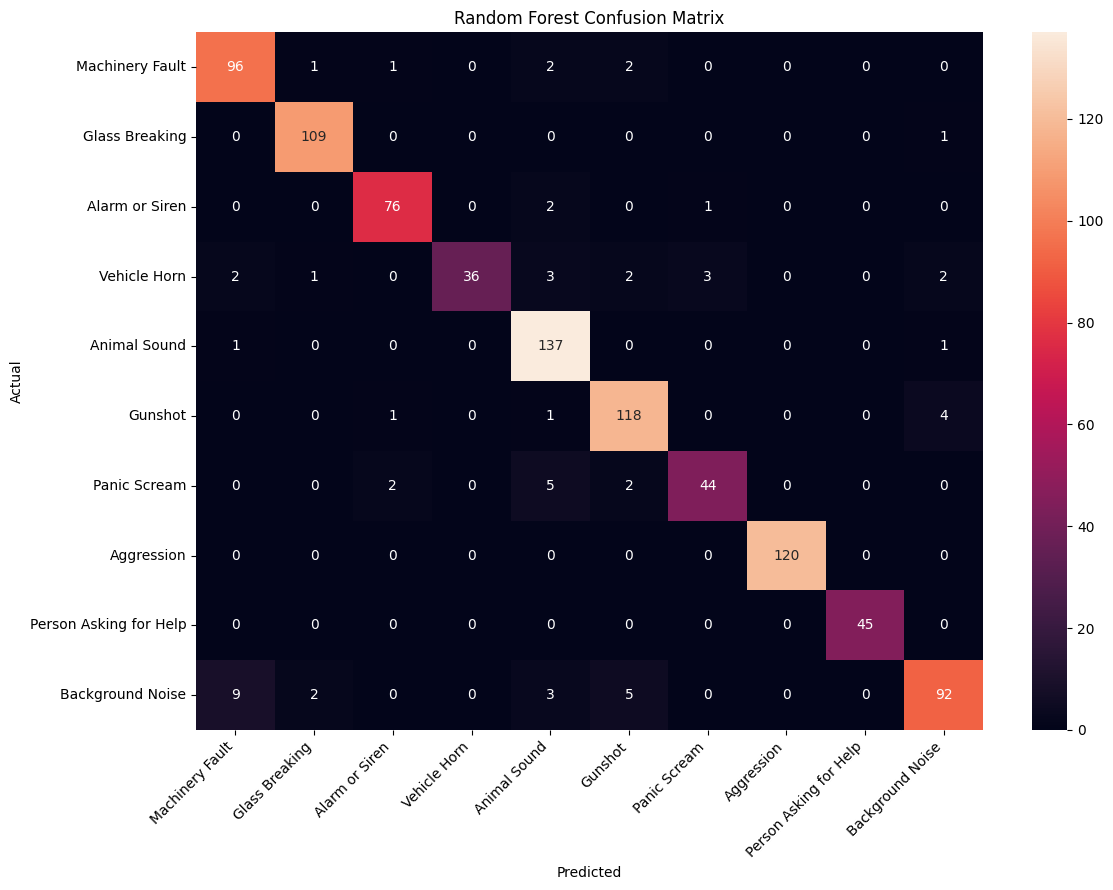

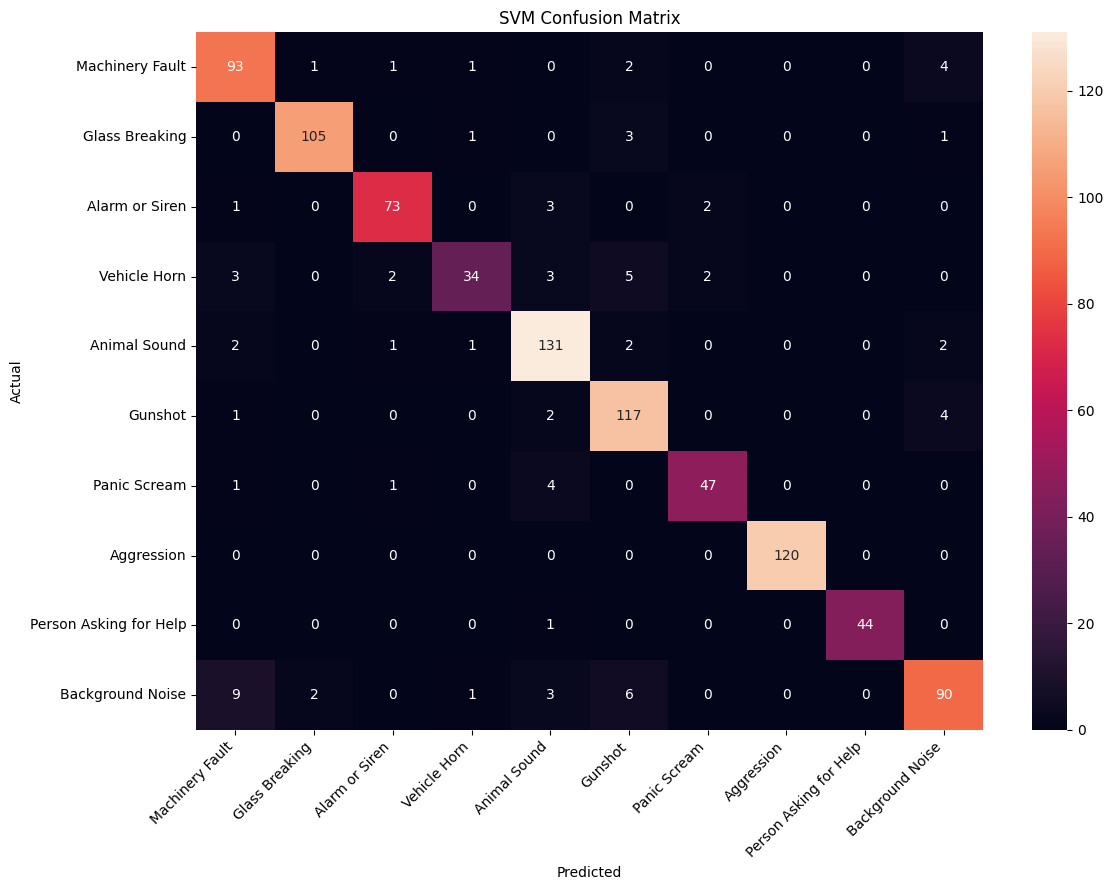

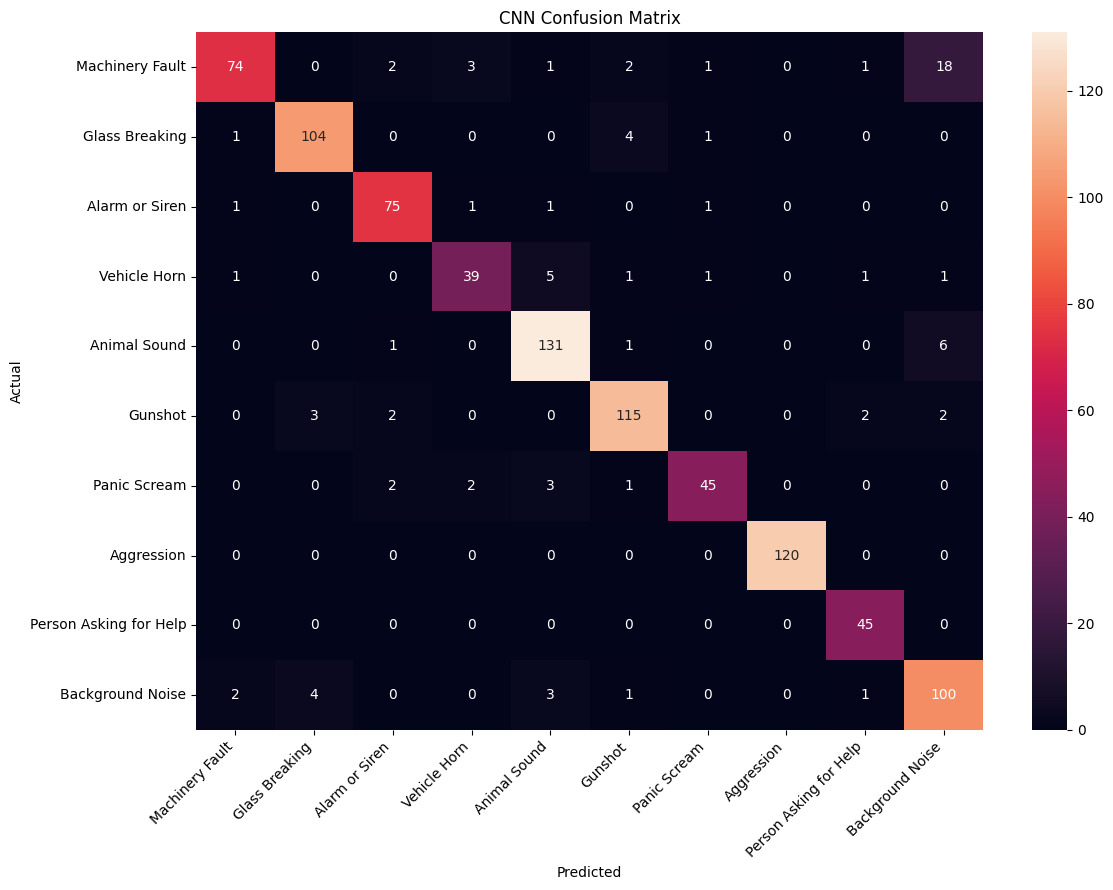

In [ ]:
def show_confusion_matrix(actual, predicted, title):
    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASSES,
        yticklabels=CLASSES
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

show_confusion_matrix(y_test, rf_pred, "Random Forest Confusion Matrix")
show_confusion_matrix(y_test, svm_pred, "SVM Confusion Matrix")
show_confusion_matrix(y_cnn_test, cnn_pred, "CNN Confusion Matrix")

## Step 19 — Plot CNN training history

This helps explain whether the CNN learned during training and how validation performance changed.

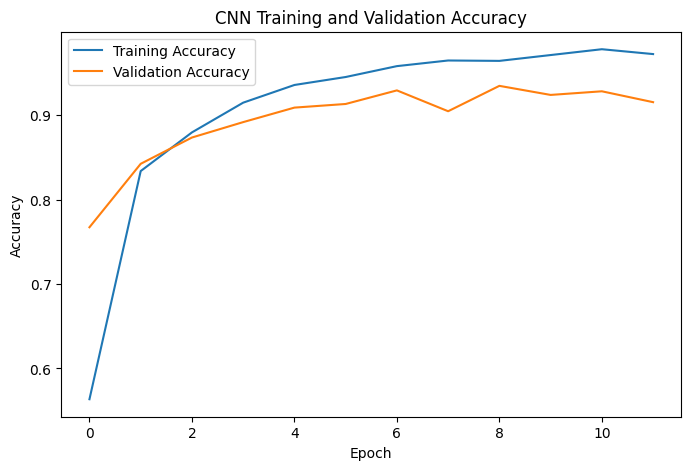

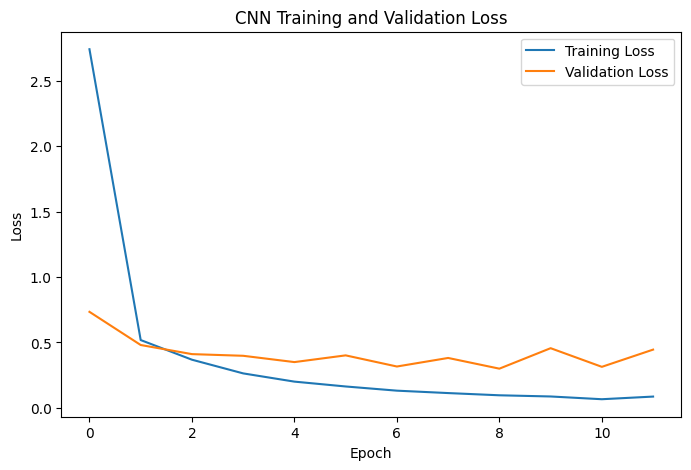

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

## Step 20 — Save trained models

The models are saved to Google Drive so they can later be connected to the SonicSentinel backend.

Only the models produced by this notebook are saved.

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/SonicSentinel/trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

import joblib


joblib.dump(svm_model, os.path.join(MODEL_DIR, "svm_model.pkl"))

cnn_model.save(os.path.join(MODEL_DIR, "cnn_model.keras"))

comparison.to_csv(
    os.path.join(MODEL_DIR, "model_comparison.csv"),
    index=False
)

print("Models saved in:", MODEL_DIR)

Models saved in: /content/drive/MyDrive/SonicSentinel/trained_models


## Step 21 — Save class labels

The backend needs the same class order when converting a model output into a class name.

In [ ]:
import json

with open(os.path.join(MODEL_DIR, "class_labels.json"), "w") as f:
    json.dump(
        {str(i): name for i, name in enumerate(CLASSES)},
        f,
        indent=2
    )

print("Class labels saved.")

Class labels saved.


## Step 22 — Simple test prediction

This cell demonstrates how one audio file can be passed through the classical model.

The confidence is taken from the model's probability output; it is not manually assigned.

In [ ]:
def predict_with_svm(file_path):
    features = extract_features(file_path)

    if features is None:
        return None

    predicted_id = int(svm_model.predict([features])[0])
    probabilities = svm_model.predict_proba([features])[0]
    confidence = float(np.max(probabilities))

    return {
        "class": id_to_class[predicted_id],
        "confidence": confidence
    }

example_file = paths_test[0]
result = predict_with_svm(example_file)

print("File:", example_file)
print("Prediction:", result)

File: /content/drive/MyDrive/SonicSentinel/Dataset/Alarm or Siren/2_fire_alarm_31.wav
Prediction: {'class': 'Alarm or Siren', 'confidence': 0.9536088466811495}


# Final notes for viva

A simple explanation of the workflow is:

**Audio file → preprocessing → feature extraction → model → predicted class + confidence**


SVM, we convert the audio into numerical acoustic features such as MFCC, Mel-spectrogram statistics, chroma, ZCR, RMS and spectral features.

For CNN, we convert the audio into a Mel-spectrogram and let the CNN learn patterns from that representation.

The final model should be selected/reported from the actual measured results rather than deciding the winner before training.

In [ ]:
from google.colab import files
import os
import shutil

MODEL_DIR = "/content/drive/MyDrive/SonicSentinel/trained_models"

# ZIP bana do
zip_path = shutil.make_archive(
    "/content/SonicSentinel_trained_models",
    "zip",
    MODEL_DIR
)

print("ZIP created:", zip_path)

files.download(zip_path)

ZIP created: /content/SonicSentinel_trained_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>